In [1]:
# LIBRARIES IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay)

In [116]:
# DATA LOAD
DATA_PATH = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"

RANDOM_STATE = 42
TEST_FRACTION = 0.20        # last 20% of quotations by date held out as the test set
MIN_CATEGORY_COUNT = 15     # categories seen fewer times than this get grouped into "infrequent"
RARE_WALLTYPE_PCT = 1.0     # wall-type flags present in fewer than this % of rows get grouped

WALL_TYPE_COLS = ['Timber_RW','RC_Pile','Steel_Beam','Sheetpile','Anchor','Block','Shotcrete',
                  'Capping_Beam','Earthwork','Concrete_Slab','Precast','Culvert','Slip_Repair',
                  'Soil_Nail','Rock_RW','Bridge','Concrete','Design_and_Build','Budget','Drill_Only',
                  'Labour_Only','Driven_Pile','Palisade','Boardwalk','Soldier','Insitu','Barrier',
                  'Noise_RW','Base','Casing','Crib','DayWork','Flood_Repair','Micro_Pile','Reno',
                  'Temp_RW','Other']

df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
print('Shape:', df_raw.shape)

Shape: (4620, 55)


# DATA EDA

In [84]:
# Explore number and percentage of missing values for each column (Naive)
info = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_missing (naive)': df_raw.isna().sum(),
    'pct_missing (naive)': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'n_unique': df_raw.nunique(),
})
info

,dtype,n_missing (naive),pct_missing (naive),n_unique
JOB NO,object,0,0.0,4618
Due_Date,object,0,0.0,988
Date,object,0,0.0,2236
CLIENT,object,0,0.0,848
ADDRESS,object,9,0.2,4527
Value,float64,0,0.0,4208
DESCRIPTION,object,0,0.0,2012
CONTACTS,object,289,6.3,2909
number_of_successful,object,4603,99.6,15
Successful,object,3428,74.2,1167


In [85]:
# Explore real percentage of missing values for text column (Actual) - Compare with Naive
SENTINELS = {'missing', 'n/a', 'na', 'unknown', 'none', 'null', '-', 'tbc', 'tbd', '?', ''}

df = df_raw.copy()
text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

sentinel_hits = {}
for c in text_cols:
    s = df[c].astype('string').str.strip()  # Convert to string and strip whitespace
    mask = s.str.lower().isin(SENTINELS)    # Case-insensitive matching
    n = int(mask.sum())                     # Count matches
    if n > 0:
        sentinel_hits[c] = n                # Track counts
        df.loc[mask, c] = pd.NA             # Replace with proper NA

comparison = pd.DataFrame({
    'pct_missing_naive': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'pct_missing_actual': (df.isna().sum() / len(df) * 100).round(1),
})
comparison['difference'] = (comparison['pct_missing_actual'] - comparison['pct_missing_naive']).round(1)
comparison[comparison['difference'] > 0].sort_values('difference', ascending=False)

,pct_missing_naive,pct_missing_actual,difference
Priced_By,0.0,37.8,37.8
Suburb,0.0,37.1,37.1
CLIENT,0.0,0.1,0.1
ADDRESS,0.2,0.3,0.1
number_of_successful,99.6,99.7,0.1
CONTACTS,6.3,6.4,0.1
Successful,74.2,74.3,0.1
Client_Clean,0.0,0.1,0.1


In [86]:
# Explore real percentage of missing values for numeric column (Actual) - Compare with Naive (EXCLUDING BINARY)

# Common numeric sentinels (excluding 0 and -1 for binary columns)
NUMERIC_SENTINELS = [-999, -9999, -99, 999, 9999, 99999, 0]

df = df_raw.copy()

# Get numeric columns BUT exclude binary columns (only 0 and 1 values)
all_numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify binary columns (only contains 0 and 1, with possible NaN)
binary_cols = []
for c in all_numeric_cols:
    unique_vals = df[c].dropna().unique()
    if set(unique_vals).issubset({0, 1}):
        binary_cols.append(c)

# Numeric columns = all numeric - binary columns
numeric_cols = [c for c in all_numeric_cols if c not in binary_cols]

print(f"📊 Numeric columns: {len(numeric_cols)}")
print(f"📊 Binary columns excluded: {len(binary_cols)}")

numeric_hits = {}
for c in numeric_cols:
    mask = df[c].isin(NUMERIC_SENTINELS)
    n = int(mask.sum())
    if n > 0:
        numeric_hits[c] = n
        df.loc[mask, c] = pd.NA

comparison = pd.DataFrame({
    'pct_missing_naive': (df_raw[numeric_cols].isna().sum() / len(df_raw) * 100).round(1),
    'pct_missing_actual': (df[numeric_cols].isna().sum() / len(df) * 100).round(1),
})
comparison['difference'] = (comparison['pct_missing_actual'] - comparison['pct_missing_naive']).round(1)
comparison[comparison['difference'] > 0].sort_values('difference', ascending=False)

📊 Numeric columns: 3
📊 Binary columns excluded: 38


,pct_missing_naive,pct_missing_actual,difference
Value,0.0,5.2,5.2
No_Wall_Types,0.0,2.7,2.7


Success
0    3431
1    1189
Name: count, dtype: int64
{0: '74.3%', 1: '25.7%'}


C:\Users\Phong\AppData\Local\Temp\ipykernel_15352\53654579.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Negative (0)', 'Positive (1)'], y=target_counts.values, ax=ax, palette=['#c0392b', '#27ae60'])


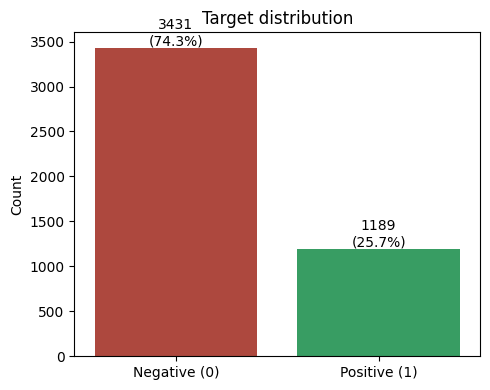

In [87]:
# Explore Target Distribution
# Purpose:  - Identifies if you have a class imbalance problem

target_counts = df['Success'].value_counts().sort_index()  # Counts how many times each unique value appears
target_pct = df['Success'].value_counts(normalize=True).sort_index() * 100   # Counts proportions instead of raw counts
print(target_counts)
print((target_pct.round(1).astype(str) + '%').to_dict())

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=['Negative (0)', 'Positive (1)'], y=target_counts.values, ax=ax, palette=['#c0392b', '#27ae60'])
ax.set_title('Target distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, f'{v}\n({target_pct.values[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

count    4.380000e+03
mean     3.489993e+05
std      1.113709e+06
min      6.510000e+02
25%      3.891875e+04
50%      9.912000e+04
75%      2.918188e+05
max      2.930183e+07
Name: Value, dtype: float64

Rows with Value <= 0: 0 (0.0%)


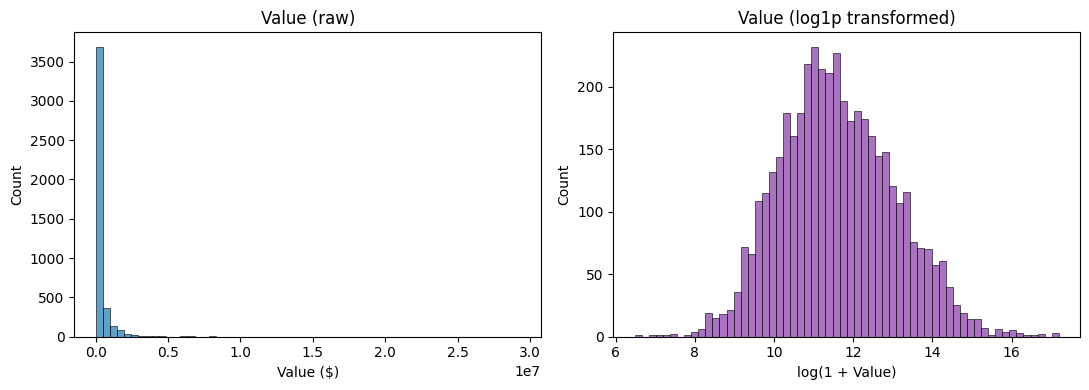

In [88]:
# Explore numeric column distriburion
# Purpose:  - # Raw values often show right-skewed distribution
#           - Most values small, few extremely large values
#           - Log transformation makes it more normal/gaussian
#           - Use log1p to handle 0 values

print(df['Value'].describe())
print()
print(f"Rows with Value <= 0: {(df['Value'] <= 0).sum()} ({(df['Value'] <= 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Value'], bins=60, ax=axes[0], color='#2980b9')
axes[0].set_title('Value (raw)')
axes[0].set_xlabel('Value ($)')

sns.histplot(np.log1p(df['Value'].clip(lower=0)), bins=60, ax=axes[1], color='#8e44ad')
axes[1].set_title('Value (log1p transformed)')
axes[1].set_xlabel('log(1 + Value)')
plt.tight_layout()
plt.show()

         mean  count
Year                
2013.0  0.311    206
2014.0  0.285    305
2015.0  0.287    275
2016.0  0.323    232
2017.0  0.304    303
2018.0  0.326    227
2019.0  0.298    285
2020.0  0.249    421
2021.0  0.311    396
2022.0  0.274    354
2023.0  0.217    447
2024.0  0.163    412
2025.0  0.188    441
2026.0  0.102    137


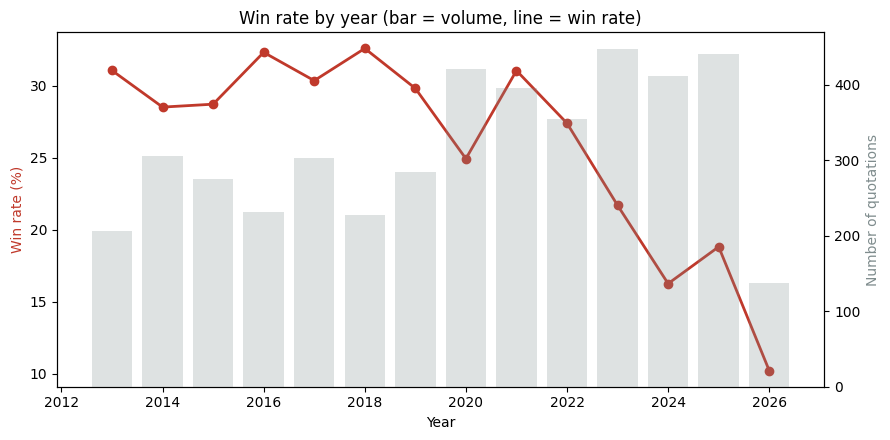

In [89]:
# Explore Target Class(1) rate over Year
# To explore the Class(1) changes over time, if the past Class(1) rate is significantly bigger than the current
# Then a random train/test split would be misleadingly optimistic
# Purpose:  - to determine if random split or time-based split is reasonable

df = df_raw.copy()

df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')
yearly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.year)['Success'].agg(['mean', 'count'])
yearly.index.name = 'Year'
print(yearly.round(3))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(yearly.index, yearly['mean']*100, marker='o', color='#c0392b', linewidth=2)
ax1.set_ylabel('Win rate (%)', color='#c0392b')
ax1.set_xlabel('Year')
ax1.set_title('Win rate by year (bar = volume, line = win rate)')

ax2 = ax1.twinx()
ax2.bar(yearly.index, yearly['count'], alpha=0.25, color='#7f8c8d')
ax2.set_ylabel('Number of quotations', color='#7f8c8d')
ax2.grid(False)
plt.tight_layout()
plt.show()

        mean  count
Month              
1.0    0.248    311
2.0    0.215    358
3.0    0.208    428
4.0    0.246    293
5.0    0.258    383
6.0    0.266    335
7.0    0.242    372
8.0    0.266    455
9.0    0.294    425
10.0   0.292    415
11.0   0.260    415
12.0   0.295    251


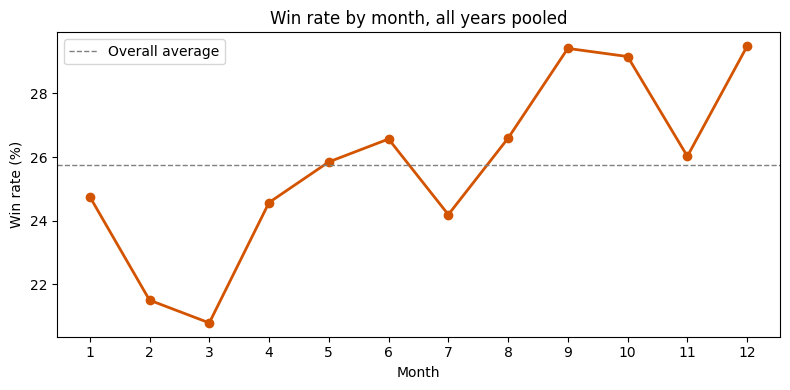

In [90]:
# Explore Target Class(1) rate over Month
# Check the Class(1) changes over the month, if it is not steady, non-monotonic, wave-shape pattern
# then the single linear Month feature can not represent, it will need cyclical encoding
# Purpose:  - to justtify for the need of cyclial encoding

df = df_raw.copy()

df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')
monthly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.month)['Success'].agg(['mean', 'count'])
monthly.index.name = 'Month'
print(monthly.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly.index, monthly['mean']*100, marker='o', color='#d35400', linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Win rate (%)')
ax.set_title('Win rate by month, all years pooled')
ax.axhline(df['Success'].mean()*100, linestyle='--', color='gray', linewidth=1, label='Overall average')
ax.legend()
plt.tight_layout()
plt.show()

In [91]:
# Explore Cardinality in Cat columns (check the uniqueness)
# Purpose:  - n_unique > 100 - High - target encoding, frequency encoding, or grouping
#           - n_unique 10-100 - Medium - One-hot encoding might work, or ordinal encoding
#           - n_unique , 10 - Low - One-hot encoding is suitable
#           
#           - pct_missing < 5% - Low - Can drop rows or impute
#           - pct_missing (5-20%) - Moderate - Impute (mode, frequency, or model-based)           
#           - pct_missing > 20% - High - Consider dropping column or careful imputation

cat_cols = ['CLIENT', 'Client_Clean', 'ADDRESS', 'Suburb', 'CONTACTS', 
            'Contact_Clean', 'Priced_By', 'DESCRIPTION']
card = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'pct_missing': (df[cat_cols].isna().sum() / len(df) * 100).round(1)
}).sort_values('n_unique', ascending=False)
card

,n_unique,pct_missing
ADDRESS,4527,0.2
CONTACTS,2909,6.3
Contact_Clean,2106,6.9
DESCRIPTION,2012,0.0
CLIENT,848,0.0
Client_Clean,799,0.0
Suburb,219,0.0
Priced_By,35,0.0


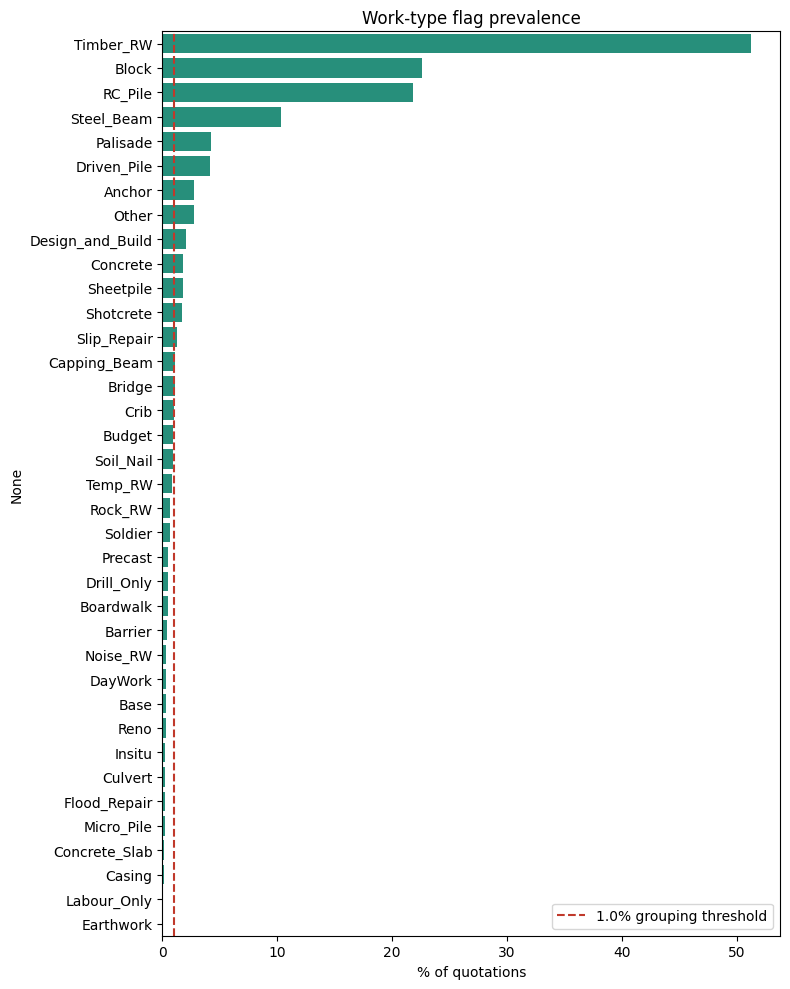

,prevalence_pct,n_rows,success_rate_when_1
Timber_RW,51.212121,2366,0.243
Block,22.640693,1046,0.280
RC_Pile,21.796537,1007,0.231
Steel_Beam,10.346320,478,0.370
Palisade,4.264069,197,0.299
Driven_Pile,4.155844,192,0.135
Anchor,2.748918,127,0.276
Other,2.727273,126,0.278
Design_and_Build,2.012987,93,0.269
Concrete,1.818182,84,0.286


In [92]:
# Explore the Binary columns - Wall type flags
# - Check how often (prevalence) of each Binary Feature(1) in data (No of rows and Percentage)
# - Check the rate of Target(1) when Binary Feature(1)
#-------------
# Purpose: - Rare Binary feature (is 1 < 1%) should be grouped into Rare Group feature   = used for now
#          - Features with extremely low prevalence might be dropped                     = used for now
#          - High prevalence + high Target(1) rate  → Strategic focus 
#          - Low prevalence + high Target(1) rate   →  Niche_Opportunity 
#          - High prevalence + high Target(1) rate  → Need investigation

prevalence = (df[WALL_TYPE_COLS].mean() * 100).sort_values(ascending=False)
success_rate = pd.Series({c: df.loc[df[c]==1, 'Success'].mean() for c in WALL_TYPE_COLS})
n_when_1 = df[WALL_TYPE_COLS].sum()

flag_summary = pd.DataFrame({
    'prevalence_pct': prevalence, 
    'n_rows': n_when_1, 
    'success_rate_when_1': success_rate.round(3)})

flag_summary = flag_summary.sort_values('prevalence_pct', ascending=False)


fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=flag_summary['prevalence_pct'], y=flag_summary.index, ax=ax, color='#16a085')
ax.axvline(RARE_WALLTYPE_PCT, color='#c0392b', linestyle='--', label=f'{RARE_WALLTYPE_PCT}% grouping threshold')
ax.set_xlabel('% of quotations')
ax.legend()
ax.set_title('Work-type flag prevalence')
plt.tight_layout()
plt.show()

flag_summary

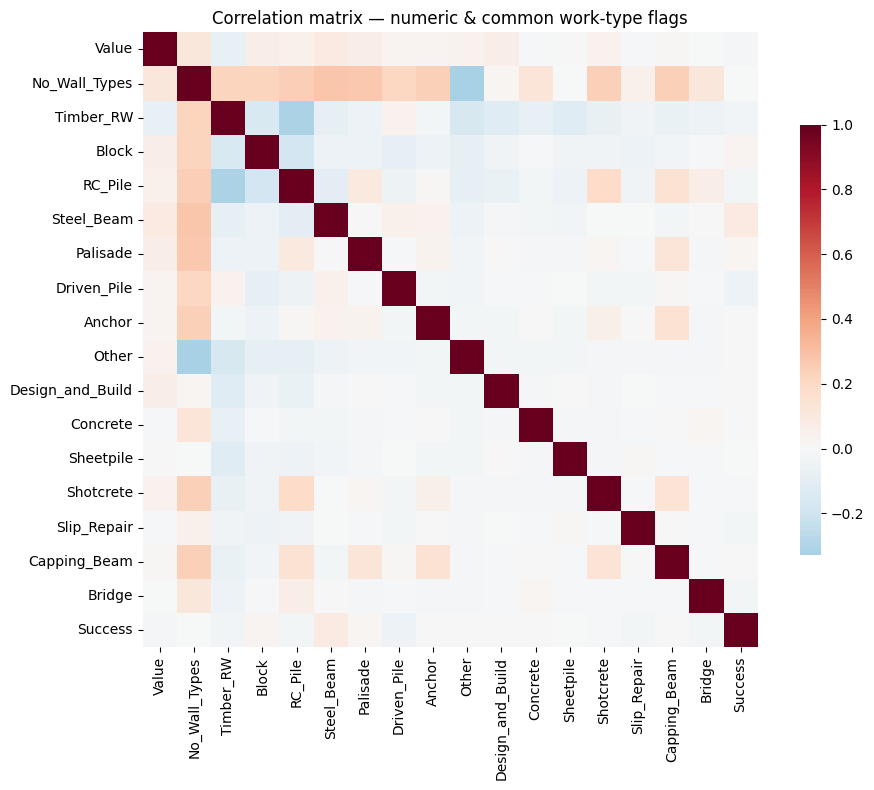

In [93]:
# Explore the Correlation
# - To check for multicollinearity among numeric features and common binary
# - Multicollinearity = When two features are highly correlated (> 0.8 or < -0.8)
# Purpose:  - Drop one of the two correlated features, Or combine them into a single feature  
#           - Features with low correlation to Target - it may not be very predictive
#           - Features with high correlation to Success - it might be important for the model


# Select Columns for Correlation Matrix:
corr_cols = ['Value', 'No_Wall_Types'] + list(flag_summary[flag_summary['prevalence_pct']>=1.0].index) + ['Success']

#  Calculates Pearson correlation coefficient between all pairs of columns
corr = df[corr_cols].corr()
# print(corr)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation matrix — numeric & common work-type flags')
plt.tight_layout()
plt.show()


In [94]:
# Explore Categorical Columns which contain more than 1 categories (by /)
# Purpose:  - Check if the multiple categories in Categorical columns worth to flag as their own feature
#           - If the multiple cat is significant, then it worths to flag


# Assess only notNA rows
priced_by_known = df[df['Priced_By'].notna()].copy()
# Split the text in categorical column by / then count how many different categories for each row, summasize into column name n_estimators
priced_by_known['n_estimators'] = priced_by_known['Priced_By'].astype(str).str.split('/').apply(lambda parts: len([p for p in parts if p.strip() != '']))

print(priced_by_known['n_estimators'].value_counts().sort_index())
print()
# Aggregate the rate of Class(1) for single vs multiple estimators (percentage of Class(1) and count of total row)
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Success'].agg(['mean', 'count']))
print()
# Median value for single vs multiple estimators
print('Median Value, single vs multiple estimators:')
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Value'].median())


n_estimators
1    4570
2      49
3       1
Name: count, dtype: int64

                  mean  count
n_estimators                 
False         0.255142   4570
True          0.460000     50

Median Value, single vs multiple estimators:
n_estimators
False     88093.5
True     423768.5
Name: Value, dtype: float64


In [ ]:
# Explore the Date columns to check how many rows has missing value as placeholder 0/01/1900
# Purpose:  - If too many missing values of Date columns - consider to drop them as unusable

import datetime
import pandas as pd

df = df_raw.copy()
for c in ['Date', 'Due_Date', 'Date_Sent']:
    # Replace Python datetime.time objects and midnight times with NaN/NaT
    df[c] = df[c].apply(lambda x: pd.NA if isinstance(x, datetime.time) else x)
    
    # Now parse safely
    parsed = pd.to_datetime(df[c], errors='coerce')
    epoch_like = parsed.dt.year <= 1900
    raw_types = df[c].map(lambda x: type(x).__name__).value_counts().to_dict()
    
    print(f'{c}: parsed range {parsed.min()} -> {parsed.max()}')
    print(f'   rows with parsed year <= 1900: {epoch_like.sum()}')
    print(f'   raw python types in this column: {raw_types}')
    print()

Date: parsed range 2013-04-04 00:00:00 -> 2026-03-31 00:00:00
   rows with parsed year <= 1900: 0
   raw python types in this column: {'datetime': 4441, 'NAType': 179}

Due_Date: parsed range 2010-08-14 00:00:00 -> 2026-05-22 00:00:00
   rows with parsed year <= 1900: 0
   raw python types in this column: {'NAType': 2920, 'datetime': 1700}

Date_Sent: parsed range 2020-03-20 00:00:00 -> 2026-09-01 00:00:00
   rows with parsed year <= 1900: 0
   raw python types in this column: {'datetime': 2426, 'NAType': 2194}



In [ ]:
# CHI-SQUARE TEST - Which features are statistically significant? ==> Later
# ================================================================

from scipy.stats import chi2_contingency
import pandas as pd

# Calculate chi-square for each wall type
chi2_results = []

for col in WALL_TYPE_COLS:
    # Create contingency table
    contingency = pd.crosstab(df[col], df['Success'])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    chi2_results.append({
        'feature': col,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'effect_size': np.sqrt(chi2 / (len(df) * (min(contingency.shape) - 1)))  # Cramer's V
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')

print("📊 Features by Statistical Significance:")
print(chi2_df)

# Show only significant features (p < 0.05)
significant_features = chi2_df[chi2_df['significant']]['feature'].tolist()
print(f"\n✅ Significant Features ({len(significant_features)}):")
print(significant_features)

In [ ]:
# =========================================================================

# DATA CLEAN

In [36]:
# Cleanup SENTINELS (text columns) and replace them with proper missing value - NA

SENTINELS = {'missing', 'n/a', 'na', 'unknown', 'none', 'null', '-', 'tbc', 'tbd', '?', ''}
df2 = df_raw.copy()
# --- sentinel cleanup (repeated here so Part 2 can run standalone after Part 1) ---
text_cols2 = df2.select_dtypes(include=['object', 'string']).columns.tolist()
for c in text_cols2:
    s = df2[c].astype('string').str.strip()   # convert to string type and remove leading/trailing whitespace
    mask = s.str.lower().isin(SENTINELS)      # convert to lower case for case-insensitive matching and check if is sentinels
    df2.loc[mask, c] = pd.NA                  # replace setinels with NA

In [37]:
# Cleanup (drop) leakage + unused raw columns

df2 = df_raw.copy()
DROP_COLS = ['Successful', 'number_of_successful', 'JOB NO', 'CLIENT', 'ADDRESS',
             'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION']
df2 = df2.drop(columns=DROP_COLS)

In [127]:
# Cleanup - remove all invalid date values in Date columns

df2 = df_raw.copy()
# Converts date columns to proper datetime format.
for c in ['Date', 'Due_Date', 'Date_Sent']:
    df2[c] = pd.to_datetime(df2[c], errors='coerce')

before_n = len(df2)   # Store original row count
df2 = df2[df2['Date'].notna()].copy()   # Keep only rows with valid dates
print(f'Dropped {before_n - len(df2)} rows with missing/invalid quote Date ({(before_n-len(df2))/before_n*100:.1f}%)')


Dropped 179 rows with missing/invalid quote Date (3.9%)


In [43]:
# Cleanup - categorical columns missing values filled with proper values as Unknow_
# Purpose:  - Fill missing values with explicit "Unknown" categories.
#           - Why: Better than dropping rows, preserves information that cat columns was unknown

df2['Client_Clean'] = df2['Client_Clean'].fillna('Unknown_Client')
df2['Suburb'] = df2['Suburb'].fillna('Unknown_Suburb')
df2['Priced_By'] = df2['Priced_By'].fillna('Unknown_Estimator').astype('string').str.strip()


In [ ]:
# ===========================================================================

# FEATURE ENGINEERING

In [40]:
# Features month and year extracted from Date columns
# Purpose:  - Extract the year, month or so on from Date columns
#           - Calculte the difference between Date columns as new feature

# --- date-derived features ---
df2['Quote_Year'] = df2['Date'].dt.year
df2['Quote_Month'] = df2['Date'].dt.month

# --- calculate the difference between Date columns ---
lead = (df2['Due_Date'] - df2['Date']).dt.days
# negative gap = bad data entry, treat as missing
lead = lead.where(lead >= 0)   # where() keeps values where condition True and replaces values with NaN where false
df2['Lead_Time_Missing'] = lead.isna().astype(int) # Binary flag indicating if lead time is missing
df2['Lead_Time_Days'] = lead

turn = (df2['Date_Sent'] - df2['Date']).dt.days
turn = turn.where(turn >= 0)
df2['Turnaround_Missing'] = turn.isna().astype(int)
df2['Turnaround_Days'] = turn

df2 = df2.drop(columns=['Due_Date', 'Date_Sent'])


In [ ]:
# Features log transformation
# Purpose:  - numeric columns which are right skewed need to be log1p transformed

# --- value transform ---
df2['Value_Log'] = np.log1p(df2['Value'].clip(lower=0))  # Replace negative values with 0 before transforming

In [42]:
# Features grouping all rare binary columns into 1 column
# Purpose:  - Calculate the percentage of (1) for binary columns

WALL_TYPE_COLS = ['Timber_RW','RC_Pile','Steel_Beam','Sheetpile','Anchor','Block','Shotcrete',
                  'Capping_Beam','Earthwork','Concrete_Slab','Precast','Culvert','Slip_Repair',
                  'Soil_Nail','Rock_RW','Bridge','Concrete','Design_and_Build','Budget','Drill_Only',
                  'Labour_Only','Driven_Pile','Palisade','Boardwalk','Soldier','Insitu','Barrier',
                  'Noise_RW','Base','Casing','Crib','DayWork','Flood_Repair','Micro_Pile','Reno',
                  'Temp_RW','Other']
RARE_WALLTYPE_PCT = 1.0  # wall-type flags present in fewer than this % of rows get grouped

wall_prevalence = df2[WALL_TYPE_COLS].mean() * 100
common_walls = wall_prevalence[wall_prevalence >= RARE_WALLTYPE_PCT].index.tolist()
rare_walls = wall_prevalence[wall_prevalence < RARE_WALLTYPE_PCT].index.tolist()
df2['Rare_WorkType'] = (df2[rare_walls].sum(axis=1) > 0).astype(int)
# drop the rare binary column after grouping them, use the grouped column
df2 = df2.drop(columns=rare_walls)

In [ ]:
# Feature columns definition - Ready for ML Pipeline

TARGET = 'Success'
NUMERIC_FEATURES = ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Quote_Month', 'Lead_Time_Days', 'Turnaround_Days']
BINARY_FEATURES = common_walls + ['Rare_WorkType', 'Lead_Time_Missing', 'Turnaround_Missing']
CATEGORICAL_FEATURES = ['Client_Clean', 'Suburb', 'Priced_By']
FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f'{len(FEATURE_COLS)} raw features going into the pipeline:')
print(f'  Numeric ({len(NUMERIC_FEATURES)}):', NUMERIC_FEATURES)
print(f'  Binary ({len(BINARY_FEATURES)}):', BINARY_FEATURES)
print(f'  Categorical ({len(CATEGORICAL_FEATURES)}, one-hot encoded below):', CATEGORICAL_FEATURES)


# SPLIT DATA

In [49]:
# Split Data by time-based split
# Training Data is the past data, Test Data is the future data
# Win rate held around 28–33% from 2013–2021, then dropped sharply: 
# 21.9% (2023) → 16.2% (2024) → 19.0% (2025) → 10.2% (2026, partial year). 
# It's roughly halved in the last three years relative to the historical average.
# This has two implications: A random train/test split would be misleadingly optimistic — 
# it would mix easier historical patterns into the test set. We'll use a time-based split so 
# the evaluation reflects predicting genuinely *future* quotations from *past* ones
# Purpose:  - Used the past data to train the Models then Predict the outcome with unseen data in future

df_sorted = df2.sort_values('Date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), 'rows |', df_sorted['Date'].iloc[:split_idx].min().date(), '->', df_sorted['Date'].iloc[:split_idx].max().date(), '| win rate:', round(y_train.mean(),3))
print('Test :', len(X_test), 'rows |', df_sorted['Date'].iloc[split_idx:].min().date(), '->', df_sorted['Date'].iloc[split_idx:].max().date(), '| win rate:', round(y_test.mean(),3))


Train: 3552 rows | 2013-04-04 -> 2024-03-26 | win rate: 0.279
Test : 889 rows | 2024-03-26 -> 2026-03-31 | win rate: 0.169


In [ ]:
#=============================================================================

In [ ]:
# Custom Date Feature Engineering
# Label missing Date, fill missing Date with median
# Extract Year, Quarter, Month, DayOfWeek and trasform them to cyclical sin and cos
# ================================================================
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    # fit method is only ever called on your training dataset, it learns the median.
    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self
    
    # transform method is called on your training data and later on your hidden test data, it uses the learned median.
    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

In [ ]:
# Numeric Feature Engineering
# Transform numeric feature using log to reduce skewness for Classification
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

In [ ]:
# Estimator Feature Engineering
# Split the values in the feature and create new columns based on that
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Multiple estimator flag
        X["MultipleEstimators"] = (
            X["EstimatorCount"] > 1
        ).astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

In [ ]:
# RareGrouper 
# ================================================================

from sklearn.base import BaseEstimator, TransformerMixin

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_frequency=10):
        self.columns = columns
        self.min_frequency = min_frequency
    
    def fit(self, X, y=None):
        X = X.copy()

        self.frequent_categories_ = {}

        for col in self.columns:

            counts = X[col].value_counts(dropna=False)

            self.frequent_categories_[col] = set(
                counts[counts >= self.min_frequency].index
            )

        return self
    
    def transform(self, X):
        X = X.copy()

        for col in self.columns:
            X[col] = np.where(
                X[col].isin(self.frequent_categories_[col]),
                X[col],
                "other"
            )

        return X
    
# Inspect the frequency distribution to determine the threshold for min frequency
client_counts = quotation_data_df["Client_Clean"].value_counts()

print(client_counts.describe())

print(client_counts.head(20))
print(client_counts.tail(20))

# Check how many grouper left with different min_frequency threshold
for threshold in [2, 5, 10, 20, 30, 50]:
    kept = (client_counts >= threshold).sum()
    print(f"{threshold:2d}: keep {kept:3d} clients")


In [ ]:
# Save dataframe after trasformation for checking
# ================================================================
from sklearn.pipeline import Pipeline

# 1. Build a preprocessing-only pipeline using your existing objects
debug_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("rare_grouper", RareCategoryGrouper(
        columns=["Client_Clean", "Suburb"],
        min_frequency=20
    )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor)
])

# 2. Fit and transform your training data to see the final numeric matrix
X_train_transformed = debug_pipeline.fit_transform(X_train)

# 3. Retrieve the post-one-hot-encoded column names from the preprocessor step
# Note: This requires scikit-learn 1.0 or newer
feature_names = debug_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 4. Reconstruct into a beautiful, readable DataFrame
transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)

# 5. Export locally to a CSV file
transformed_df.to_csv(r"C:\Users\Phong\Downloads\Quotation Data Test.csv", index=False)

print(f"✅ Success! Exported a matrix of {transformed_df.shape[0]} rows and {transformed_df.shape[1]} columns.")
print("Check your local directory for 'transformed_training_data.csv'.")

In [ ]:
# Save Trained Model and make prediction from local file - Classification
from joblib import dump

dump(lgr_best_model_v3, "LogisticRegression_V3.joblib")
print("Model saved.")

# Make Classification Prediction from data file
import pandas as pd
from joblib import load

# ==========================================
# Load trained model
# ==========================================
model = load("LogisticRegression_V3.joblib")

# ==========================================
# Load Excel file
# ==========================================
new_df = pd.read_excel(r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data Test.xlsx")

# ==========================================
# Keep only raw features
# ==========================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

X_new = new_df[raw_features]

# ==========================================
# Predict
# ==========================================
pred_class = model.predict(X_new)

pred_probability = model.predict_proba(X_new)

# Probability of Profit (class=1)
profit_probability = pred_probability[:,1]

loss_probability = pred_probability[:,0]

# ==========================================
# Save predictions
# ==========================================
new_df["Prediction"] = pred_class

new_df["Prediction_Label"] = new_df["Prediction"].map({
    0:"Lost",
    1:"Won"
})

new_df["Probability_Won"] = profit_probability

new_df["Probability_Lost"] = loss_probability

# ==========================================
# Save CSV
# ==========================================
output_file = r"C:\Users\Phong\Downloads\Quotation Prediction.csv"

new_df.to_csv(output_file, index=False)
print(f"Prediction saved to:\n{output_file}")

In [2]:
# Analysis Data 01 - Grouping unique value of Feature 
# to calculate: "size" - total number for unique value of Feature in column "Success"
# to calculate: "mean" - average for unique value of Feature in column "Success" 
summary = (
    quotation_data_df
    .groupby("Priced_By")
    .agg(
        Quotes=("Success", "size"),
        WinRate=("Success", "mean")
    )
    .sort_values("Quotes", ascending=False)
)

print(summary)

                       Quotes   WinRate
Priced_By                              
MISSING                  1746  0.146621
ZEINAB                   1012  0.303360
SHERYL                    906  0.352097
GARY                      355  0.309859
SANTI                     119  0.201681
CIARAN                     99  0.222222
CHRIS                      97  0.649485
MARK                       87  0.321839
HITESH                     61  0.114754
OLRIC                      35  0.200000
EGIDIO                     26  0.076923
GARY / SHERYL              17  0.352941
GARY / ZEINAB               9  0.555556
SHERYL / HITESH             8  0.375000
DEEP                        8  1.000000
GARY / HITESH               6  0.500000
DEAN                        5  0.800000
SHERYL / EGIDIO             3  0.333333
CB                          2  0.500000
SHERYL /  MARK              2  0.500000
RIAAN                       2  0.500000
STEFANO                     2  1.000000
ANDRE                       1  1.000000
